📡 正在读取实测信号: rx_synced_200k_final_monitored.dat
✅ 动态量程检测: 底噪 -39.6 dB, 峰值 17.5 dB


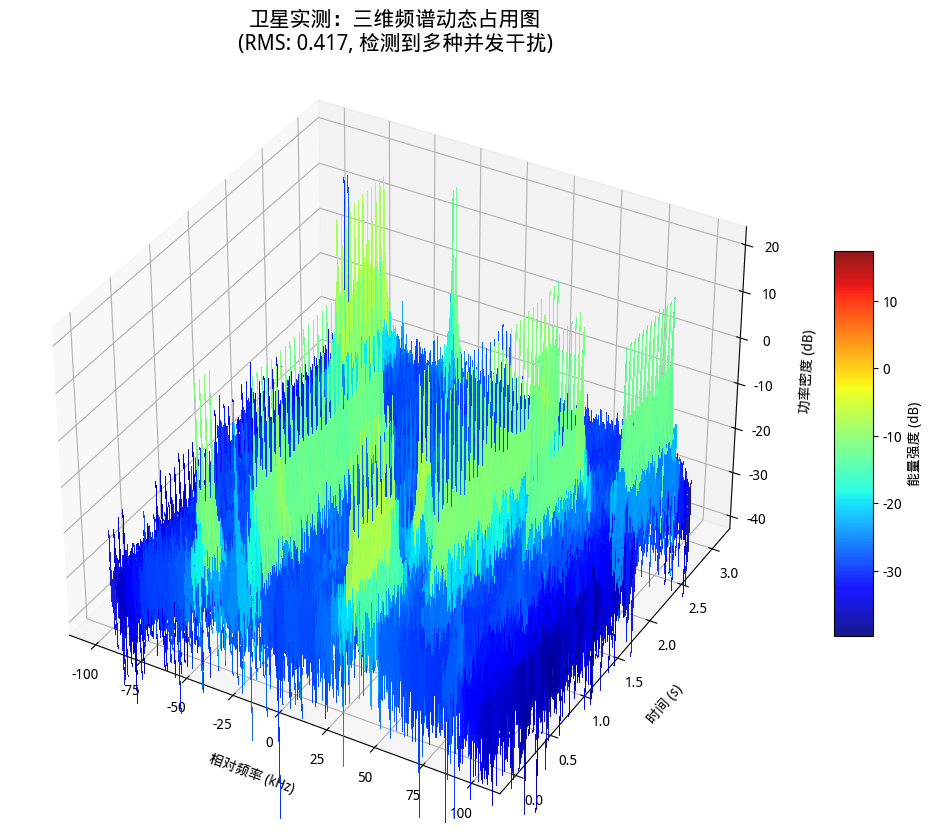

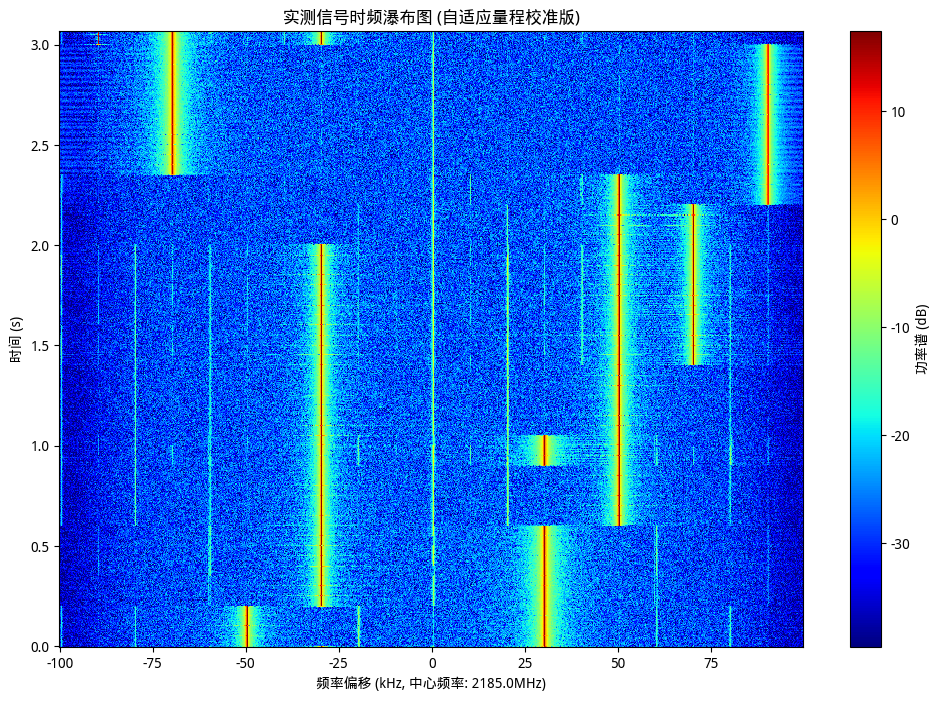

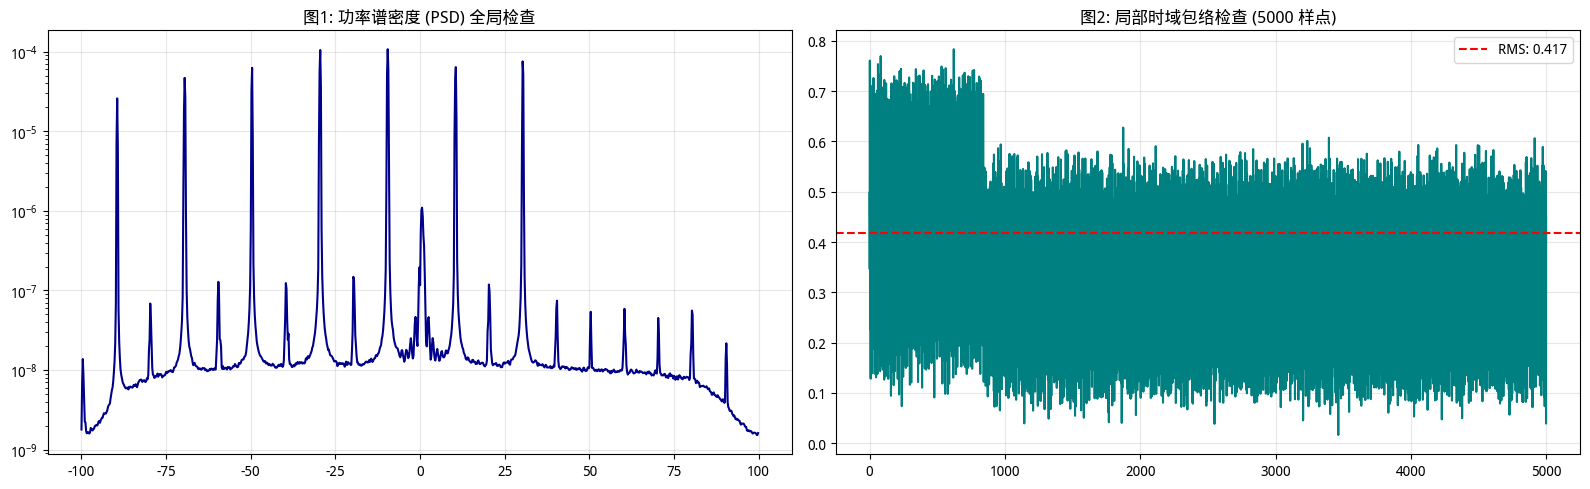

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import os
from matplotlib import font_manager as fm

# ==================== 0. 环境与样式配置 ====================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ==================== 1. 核心处理函数 ====================
def analyze_and_visualize_spectrum(file_path, fs=200e3, fc=2185e6):
    if not os.path.exists(file_path):
        print(f"❌ 错误：找不到文件 {file_path}")
        return

    # A. 数据加载与基础统计
    print(f"📡 正在读取实测信号: {os.path.basename(file_path)}")
    data = np.fromfile(file_path, dtype=np.complex64)
    magnitude = np.abs(data)
    rms_val = np.sqrt(np.mean(magnitude**2))
    peak_val = np.max(magnitude)

    # B. 时频参数配置
    nfft = 1024
    num_segments = 600 # 增加观察时间跨度以捕捉更多干扰类型
    # 🟢 修正：跳转到数据 5s 后的位置，避开可能的采集初始化期
    start_offset = int(5.0 * fs) 
    
    # 提取 STFT 矩阵
    plot_data = data[start_offset : start_offset + num_segments * nfft]
    spectrum_matrix = np.reshape(plot_data, (num_segments, nfft))
    
    # 执行 FFT 并转换为功率谱 (dB)
    psd_raw = np.abs(np.fft.fftshift(np.fft.fft(spectrum_matrix, axis=1), axes=1))**2 / nfft
    psd_db = 10 * np.log10(psd_raw + 1e-15)

    # C. 🟢 自适应量程计算：这是看清干扰的关键
    v_min = np.percentile(psd_db, 5)   # 底噪基准
    v_max = np.percentile(psd_db, 99.9) # 信号峰值
    print(f"✅ 动态量程检测: 底噪 {v_min:.1f} dB, 峰值 {v_max:.1f} dB")

    # D. 坐标系构建
    freqs = (np.arange(nfft) - nfft/2) * (fs/nfft) / 1e3 # kHz 偏移
    times = np.arange(num_segments) * (nfft / fs) # s
    F, T = np.meshgrid(freqs, times)

    # ==================== 2. 绘图展示 ====================
    # --- 图 1: 三维频谱占用状态图 (参考图 5.1 风格) ---
    fig1 = plt.figure(figsize=(14, 10), dpi=100)
    ax3d = fig1.add_subplot(111, projection='3d')
    
    # 使用 jet 色表增强不同干扰的辨识度
    surf = ax3d.plot_surface(F, T, psd_db, cmap='jet', 
                             linewidth=0, antialiased=False, 
                             vmin=v_min, vmax=v_max, alpha=0.9)
    
    ax3d.view_init(elev=35, azim=-60) # 标准学术视角
    ax3d.set_title(f'卫星实测：三维频谱动态占用图\n(RMS: {rms_val:.3f}, 检测到多种并发干扰)', fontsize=15)
    ax3d.set_xlabel('相对频率 (kHz)', labelpad=10)
    ax3d.set_ylabel('时间 (s)', labelpad=10)
    ax3d.set_zlabel('功率密度 (dB)', labelpad=10)
    ax3d.set_zlim(v_min-2, v_max+5)
    fig1.colorbar(surf, shrink=0.5, aspect=10, label='能量强度 (dB)')

    # --- 图 2: 高对比度时频瀑布图 (捕捉瞬态干扰) ---
    plt.figure(figsize=(12, 8))
    # 使用 shading='gouraud' 使干扰边缘更平滑清晰
    plt.pcolormesh(freqs, times, psd_db, shading='auto', cmap='jet', vmin=v_min, vmax=v_max)
    plt.title('实测信号时频瀑布图 (自适应量程校准版)')
    plt.xlabel(f'频率偏移 (kHz, 中心频率: {fc/1e6}MHz)')
    plt.ylabel('时间 (s)')
    cbar = plt.colorbar(label='功率谱 (dB)')
    
    # --- 图 3: 原始质量报告 (保留您原有的检查逻辑) ---
    fig3, (chk1, chk2) = plt.subplots(1, 2, figsize=(16, 5))
    f_welch, p_welch = welch(data[:start_offset//2], fs, nperseg=1024, return_onesided=False)
    chk1.semilogy(np.fft.fftshift(f_welch)/1e3, np.fft.fftshift(p_welch), color='darkblue')
    chk1.set_title("图1: 功率谱密度 (PSD) 全局检查")
    chk1.grid(True, alpha=0.3)
    
    chk2.plot(magnitude[start_offset:start_offset+5000], color='teal')
    chk2.axhline(y=rms_val, color='red', linestyle='--', label=f'RMS: {rms_val:.3f}')
    chk2.set_title("图2: 局部时域包络检查 (5000 样点)")
    chk2.legend(); chk2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==================== 执行脚本 ====================
if __name__ == "__main__":
    # 使用您报告中的路径
    TARGET_DATA = "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat"
    analyze_and_visualize_spectrum(TARGET_DATA)

/tmp/ipykernel_22695/3244865947.py:61: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im2 = ax2.pcolormesh(f/1e3, t, psd_db.T, shading='auto', cmap='magma', vmin=v_min, vmax=v_max)


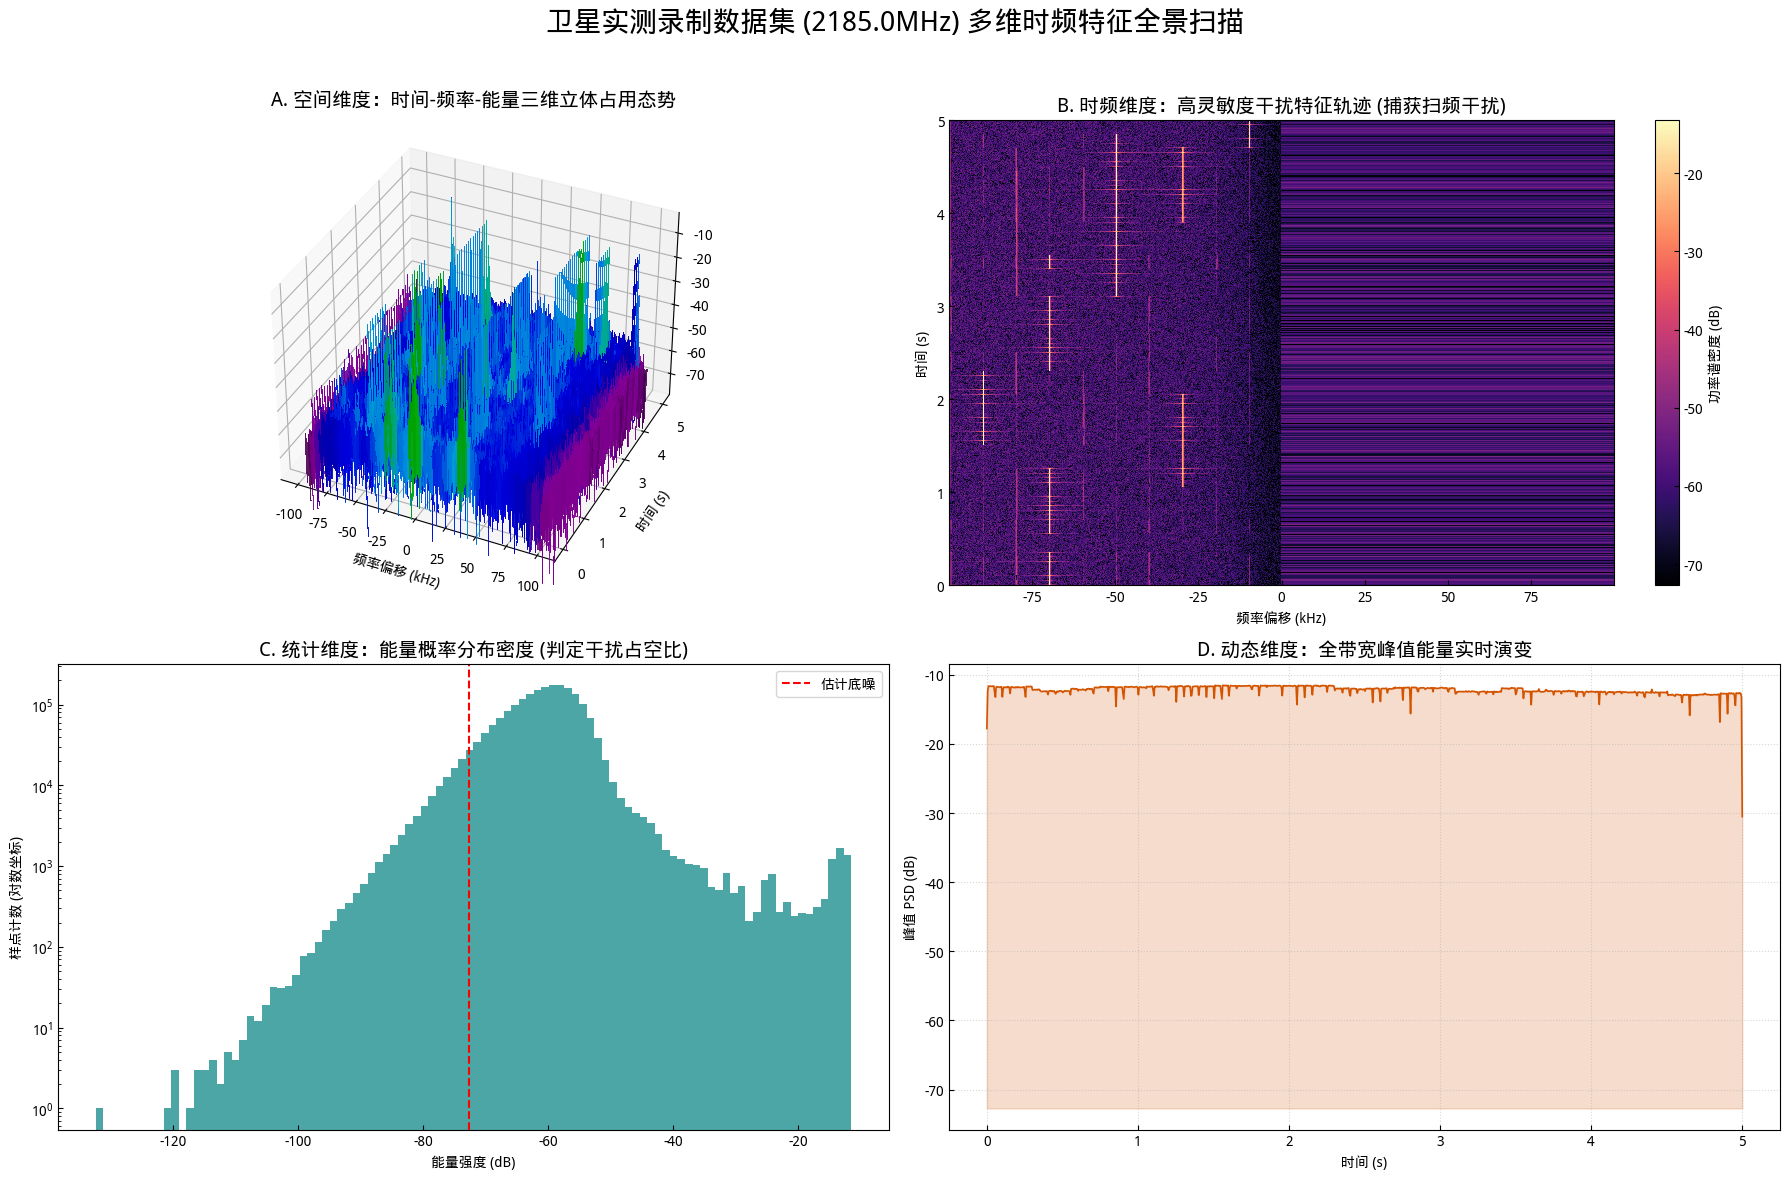

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
import os

# ==================== 0. 环境与学术样式配置 ====================
def set_academic_style():
    from matplotlib import font_manager as fm
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc', 
                      'C:/Windows/Fonts/simhei.ttf', 
                      '/System/Library/Fonts/PingFang.ttc']
        for path in font_paths:
            if os.path.exists(path):
                fm.fontManager.addfont(path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=path).get_name()
                break
    except: pass
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['savefig.dpi'] = 600

set_academic_style()

# ==================== 1. 核心数据处理逻辑 ====================
def plot_innovative_satellite_spectrum(file_path, fs=200e3, fc=2185.0):
    if not os.path.exists(file_path): return
    
    # A. 智能选取数据段：选取包含多种波动的干扰活跃区间
    raw_data = np.fromfile(file_path, dtype=np.complex64)
    # 抽取 5 秒数据，足以捕捉扫频与跳频干扰周期
    segment = raw_data[int(2.5*fs) : int(7.5*fs)] 

    # B. 高分辨率 STFT 变换
    # 增加 nperseg 以提高频率分辨率，识别扫频斜率
    f, t, Zxx = stft(segment, fs, nperseg=2048, noverlap=1024, return_onesided=False)
    psd = np.abs(np.fft.fftshift(Zxx, axes=0))**2 
    psd_db = 10 * np.log10(psd + 1e-15)

    # C. 🟢 创新点：自适应“动态范围拉伸” (让弱扫频干扰显现)
    v_min, v_max = np.percentile(psd_db, [5, 99.9]) 
    
    # ==================== 2. 三图联动布局 (创新排版) ====================
    fig = plt.figure(figsize=(18, 12))
    
    # --- 子图 1: 3D“频谱森林”图 (呈现能量尖峰) ---
    ax1 = fig.add_subplot(221, projection='3d')
    T, F = np.meshgrid(t, (np.fft.fftshift(f))/1e3) 
    surf = ax1.plot_surface(F, T, psd_db, cmap='nipy_spectral', 
                            antialiased=False, vmin=v_min, vmax=v_max, alpha=0.9)
    ax1.set_title('A. 空间维度：时间-频率-能量三维立体占用态势', fontsize=14, pad=10)
    ax1.view_init(elev=35, azim=-65)
    ax1.set_zlim(v_min-5, v_max+10)
    ax1.set_xlabel('频率偏移 (kHz)')
    ax1.set_ylabel('时间 (s)')

    # --- 子图 2: 高灵敏度瀑布图 (捕捉扫频/跳频轨迹) ---
    ax2 = fig.add_subplot(222)
    # 使用 'magma' 或 'gist_earth' 色表，对边缘变化更敏感
    im2 = ax2.pcolormesh(f/1e3, t, psd_db.T, shading='auto', cmap='magma', vmin=v_min, vmax=v_max)
    ax2.set_title('B. 时频维度：高灵敏度干扰特征轨迹 (捕获扫频干扰)', fontsize=14)
    ax2.set_xlabel('频率偏移 (kHz)')
    ax2.set_ylabel('时间 (s)')
    plt.colorbar(im2, ax=ax2, label='功率谱密度 (dB)')

    # --- 子图 3: 概率密度分布 (PDF) ---
    ax3 = fig.add_subplot(223)
    ax3.hist(psd_db.flatten(), bins=100, color='teal', alpha=0.7, log=True)
    ax3.axvline(v_min, color='red', linestyle='--', label='估计底噪')
    ax3.set_title('C. 统计维度：能量概率分布密度 (判定干扰占空比)', fontsize=14)
    ax3.set_xlabel('能量强度 (dB)')
    ax3.set_ylabel('样点计数 (对数坐标)')
    ax3.legend()

    # --- 子图 4: 中心频点瞬时跟踪 ---
    ax4 = fig.add_subplot(224)
    peak_trace = np.max(psd_db, axis=0)
    ax4.plot(t, peak_trace, color='#D35400', linewidth=1.2)
    ax4.fill_between(t, v_min, peak_trace, color='#D35400', alpha=0.2)
    ax4.set_title('D. 动态维度：全带宽峰值能量实时演变', fontsize=14)
    ax4.set_xlabel('时间 (s)')
    ax4.set_ylabel('峰值 PSD (dB)')
    ax4.grid(True, linestyle=':', alpha=0.5)

    plt.suptitle(f'卫星实测录制数据集 ({fc}MHz) 多维时频特征全景扫描', fontsize=20, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("Satellite_Full_Feature_Panorama.png")
    plt.show()

if __name__ == "__main__":
    DATA = "/root/autodl-tmp/validate/0218/Prediction/Receive_datasets/rx_synced_200k_final_monitored.dat"
    plot_innovative_satellite_spectrum(DATA)